In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Modelado
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression # Para análisis de coeficientes base
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Guardado del modelo
import joblib

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Carga de datos usando ruta relativa según estructura del proyecto
try:
    df = pd.read_csv('../../data/raw/LifeExpectancyData_raw.csv')
    print("✅ Datos cargados correctamente.")
except FileNotFoundError:
    # Fallback por si el nombre del archivo es diferente en tu local
    print("⚠️ Archivo no encontrado en la ruta relativa. Intentando carga directa (ajusta si es necesario).")
    # df = pd.read_csv('LifeExpectancyData.csv') # Descomentar si es necesario

# 1. Limpieza de nombres de columnas (Trim whitespace)
df.columns = df.columns.str.strip()

# 2. Eliminación de filas donde el TARGET es nulo (No podemos aprender sin la respuesta)
df = df.dropna(subset=['Life expectancy'])

# 3. Vista preliminar
print(f"Dimensiones del dataset: {df.shape}")
df.head()

✅ Datos cargados correctamente.
Dimensiones del dataset: (2928, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [5]:
# Conteo de nulos
nulls = df.isnull().sum()
print(nulls[nulls > 0])

# Imputación Estratégica:
# En lugar de eliminar, rellenaremos los nulos dentro del pipeline para evitar Data Leakage.
# Sin embargo, para el EDA, haremos una imputación temporal.
df_eda = df.copy()
numeric_cols = df_eda.select_dtypes(include=np.number).columns
# Rellenamos con la mediana (más robusta a outliers que la media)
for col in numeric_cols:
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

Alcohol                            193
Hepatitis B                        553
BMI                                 32
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                443
Population                         644
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64


## EDA

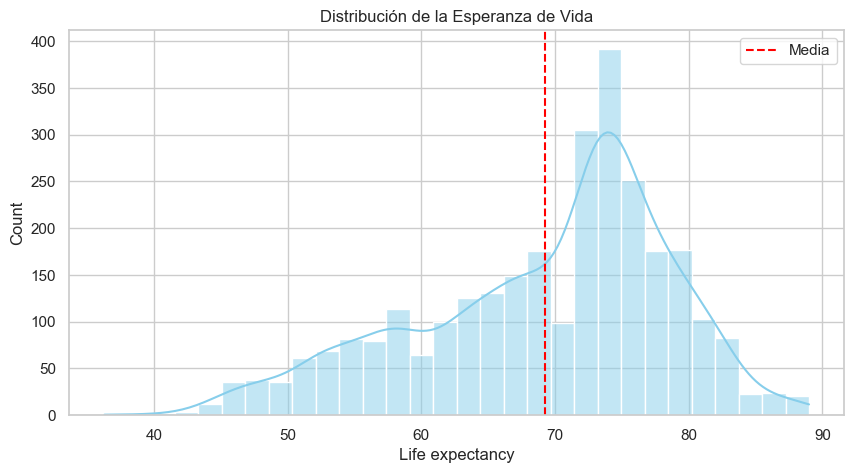

In [6]:
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['Life expectancy'], kde=True, color='skyblue')
plt.title('Distribución de la Esperanza de Vida')
plt.axvline(df_eda['Life expectancy'].mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.show()

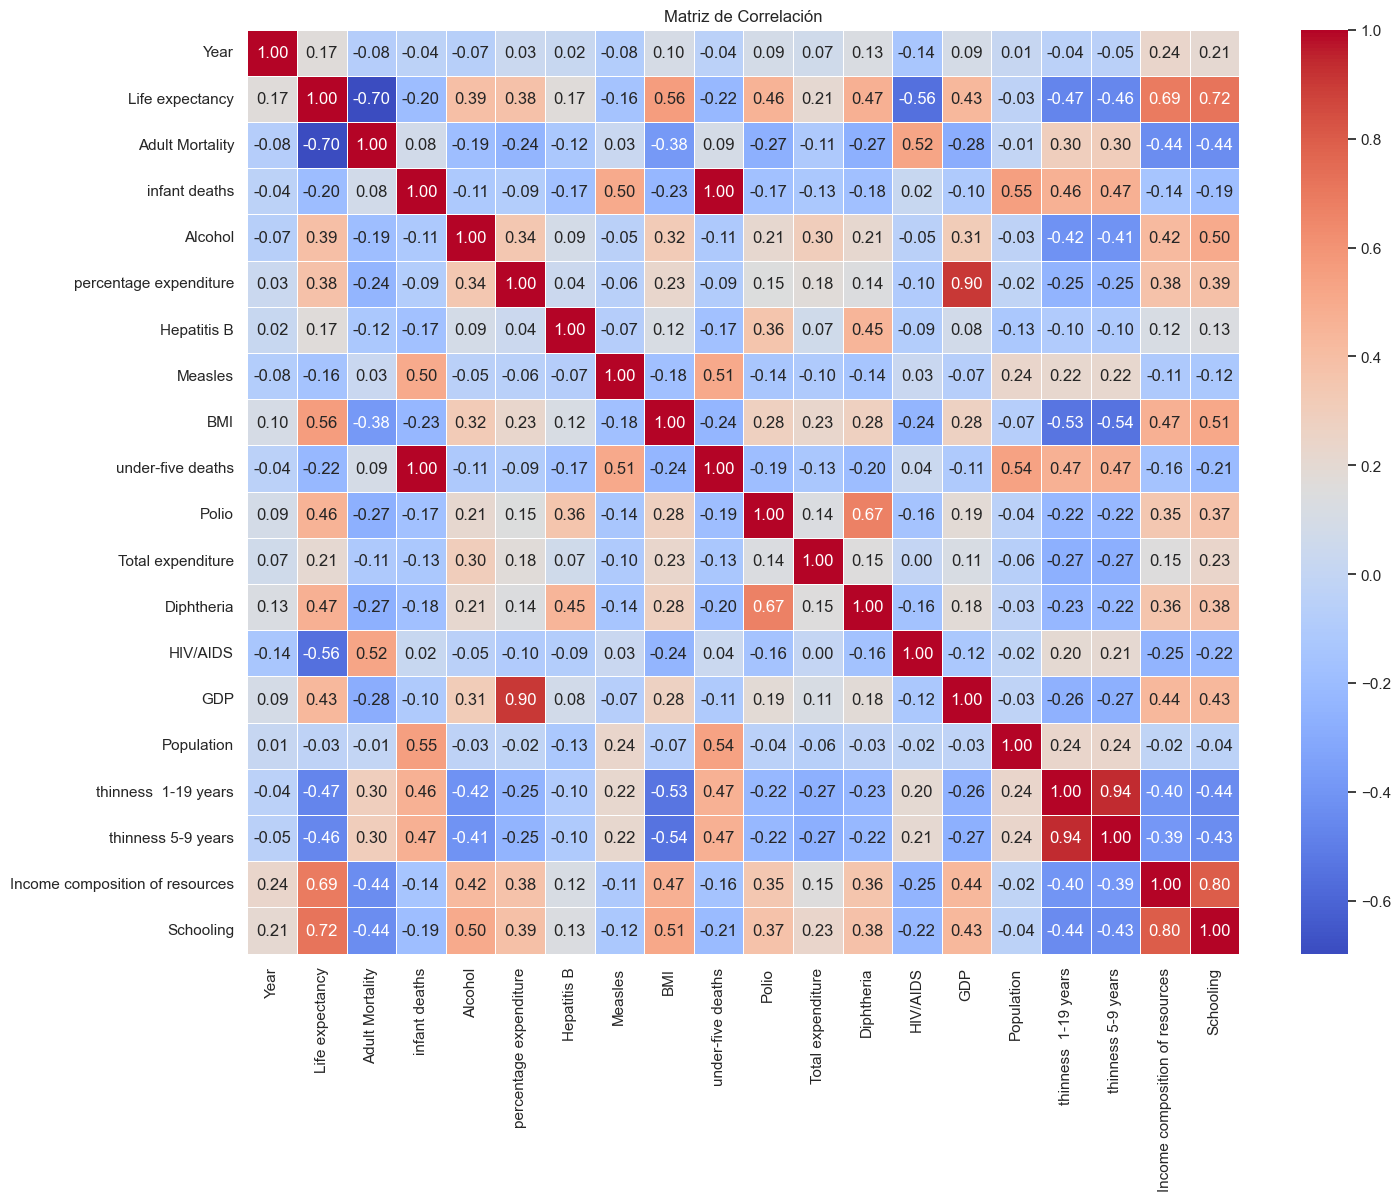

In [7]:
plt.figure(figsize=(16, 12))
corr_matrix = df_eda.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

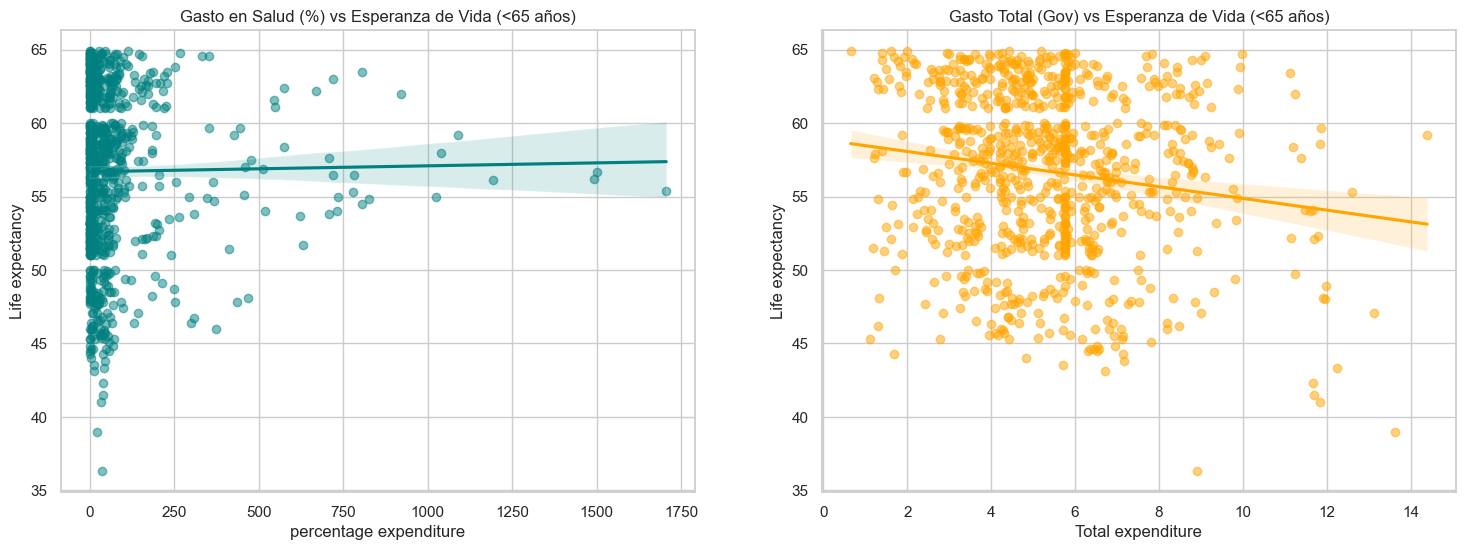

In [8]:
# Filtramos países con baja esperanza de vida
low_le = df_eda[df_eda['Life expectancy'] < 65]

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: Gasto porcentual vs Esperanza de Vida
sns.regplot(x='percentage expenditure', y='Life expectancy', data=low_le, ax=ax[0], scatter_kws={'alpha':0.5}, color='teal')
ax[0].set_title('Gasto en Salud (%) vs Esperanza de Vida (<65 años)')

# Gráfico 2: Total Expenditure (Gov) vs Esperanza de Vida
sns.regplot(x='Total expenditure', y='Life expectancy', data=low_le, ax=ax[1], scatter_kws={'alpha':0.5}, color='orange')
ax[1].set_title('Gasto Total (Gov) vs Esperanza de Vida (<65 años)')

plt.show()

## Eliminar columnas inncesarias

In [9]:
# -------------------------------------------------------------------------
# PASO 5: Preprocesamiento y Feature Engineering (ACTUALIZADO SEGÚN EDA)
# -------------------------------------------------------------------------

# 1. Selección de Features (Feature Selection)
# Basado en la matriz de correlación, eliminamos redundancia y ruido:
features_to_drop = [
    'Life expectancy',        # Target
    'Country',                # Variable categórica con demasiada cardinalidad
    'Year',                   # No estamos haciendo series temporales
    'under-five deaths ',     # Correlación 1.00 con infant deaths (Redundante)
    'percentage expenditure', # Correlación 0.90 con GDP (Redundante)
    ' thinness 5-9 years',    # Correlación 0.94 con thinness 1-19 (Redundante)
    'Population'              # Correlación -0.03 (Irrelevante/Ruido)
]

# Definimos X e y
# Usamos 'errors=ignore' por si alguna columna ya fue borrada o tiene el nombre ligeramente distinto
X = df.drop(features_to_drop, axis=1, errors='ignore')
y = df['Life expectancy']

print(f"Features seleccionadas para el modelo ({X.shape[1]} variables):")
print(X.columns.tolist())

# 2. Split Train/Test (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Pipeline de Preprocesamiento
# Identificamos columnas numéricas y categóricas automáticamente
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

# Pipeline para numéricas: Imputar mediana (robustez) + Estandarizar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para categóricas (Status): Imputar + OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Unimos todo en el Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Pipeline de preprocesamiento configurado y optimizado.")

Features seleccionadas para el modelo (17 variables):
['Status', 'Adult Mortality', 'infant deaths', 'Alcohol', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']
✅ Pipeline de preprocesamiento configurado y optimizado.


## RANDOM FOREST

In [10]:
# Definir el Pipeline completo
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(random_state=42))])

# Grid de Hiperparámetros
param_grid = {
    'regressor__n_estimators': [100, 200], # Número de árboles
    'regressor__max_depth': [10, 20, None], # Profundidad máxima (controla overfitting)
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

# Búsqueda (GridSearchCV incluye Cross-Validation interna)
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)

print("Entrenando modelo (esto puede tardar unos segundos)...")
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Entrenando modelo (esto puede tardar unos segundos)...
Mejores parámetros: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}


## Evaluación de rendimiento

In [11]:
# Predicciones
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Métricas
def evaluate_model(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {set_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    return r2

r2_train = evaluate_model(y_train, y_train_pred, "TRAIN")
r2_test = evaluate_model(y_test, y_test_pred, "TEST")

# Check de Overfitting
overfitting_pct = (r2_train - r2_test) * 100
print(f"\nDiferencia R² (Overfitting): {overfitting_pct:.2f}%")

if overfitting_pct < 5:
    print("✅ CRITERIO CUMPLIDO: Overfitting inferior al 5%.")
else:
    print("⚠️ ALERTA: Posible overfitting. Se recomienda aumentar regularización (max_depth).")

--- TRAIN ---
RMSE: 0.6859
MAE:  0.4286
R²:   0.9949
--- TEST ---
RMSE: 1.7120
MAE:  1.0460
R²:   0.9661

Diferencia R² (Overfitting): 2.88%
✅ CRITERIO CUMPLIDO: Overfitting inferior al 5%.


## Respuesta a la pregunta 1

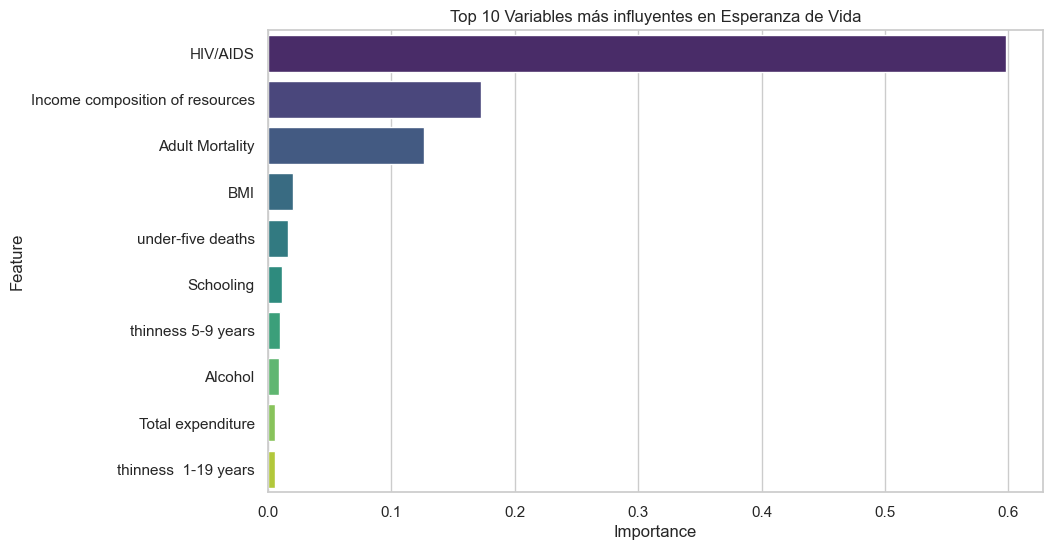

In [12]:
# Extraer nombres de features tras el OneHotEncoding
ohe_cols = best_model.named_steps['preprocessor'].transformers_[1][1]['onehot'].get_feature_names_out(categorical_features)
feature_names = np.r_[numeric_features, ohe_cols]

# Extraer importancias
importances = best_model.named_steps['regressor'].feature_importances_

# Crear DataFrame
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(10)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title('Top 10 Variables más influyentes en Esperanza de Vida')
plt.show()

## Pipeline

In [13]:
import os

# Crear carpeta models si no existe
os.makedirs('../../models', exist_ok=True)

# Guardar pipeline completo
joblib.dump(best_model, '../../models/life_expectancy_model.pkl')
print("✅ Modelo guardado en ../../models/life_expectancy_model.pkl")

✅ Modelo guardado en ../../models/life_expectancy_model.pkl


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# ==============================================================================
# 10. PRODUCTIVIZACIÓN: SIMULADOR (CORREGIDO - SIN ESPACIOS EN NOMBRES)
# ==============================================================================

print("🏥 SIMULADOR DE ESPERANZA DE VIDA (EJECUTIVO)")
print("Ajuste los valores a continuación para predecir:")

# --- 1. Definición de Widgets ---
style = {'description_width': 'initial'}

w_schooling = widgets.FloatSlider(value=10.0, min=0, max=21.0, step=0.1, description='Años de Escolaridad:', style=style)
w_income = widgets.FloatSlider(value=0.5, min=0, max=1.0, step=0.01, description='Índice de Recursos (0-1):', style=style)
w_hiv = widgets.FloatSlider(value=0.1, min=0.1, max=50.0, step=0.1, description='VIH/SIDA (muertes/1000):', style=style)
w_adult_mort = widgets.IntSlider(value=200, min=0, max=1000, step=10, description='Mortalidad Adultos:', style=style)
w_bmi = widgets.FloatSlider(value=40.0, min=10.0, max=80.0, step=0.1, description='BMI Promedio:', style=style)
w_gdp = widgets.FloatText(value=5000.0, description='PIB per Cápita ($):', style=style)
w_status = widgets.Dropdown(options=['Developing', 'Developed'], value='Developing', description='Estatus del País:', style=style)
w_polio = widgets.IntSlider(value=80, min=0, max=100, step=1, description='Vacunación Polio (%):', style=style)

button = widgets.Button(description="🔮 Calcular Esperanza de Vida", button_style='success')
output = widgets.Output()

# --- 2. Lógica de Predicción Corregida ---
def on_button_clicked(b):
    with output:
        clear_output()
        
        # Diccionario CORREGIDO: Nombres de claves sin espacios extra (Clean names)
        # y eliminando las columnas que sabemos que borraste (under-five, thinness 5-9)
        data_completa = {
            'Status': [w_status.value],
            'Adult Mortality': [w_adult_mort.value],
            'infant deaths': [30],
            'Alcohol': [4.5],
            # 'percentage expenditure': [0], # Eliminada en limpieza
            'Hepatitis B': [80],
            'Measles': [200],              # CORREGIDO: 'Measles ' -> 'Measles'
            'BMI': [w_bmi.value],          # CORREGIDO: ' BMI ' -> 'BMI'
            # 'under-five deaths': [40],   # Eliminada en limpieza
            'Polio': [w_polio.value],
            'Total expenditure': [6.0],
            'Diphtheria': [w_polio.value], # CORREGIDO: 'Diphtheria ' -> 'Diphtheria'
            'HIV/AIDS': [w_hiv.value],     # CORREGIDO: ' HIV/AIDS' -> 'HIV/AIDS'
            'GDP': [w_gdp.value],
            # 'Population': [1e6],         # Eliminada en limpieza
            'thinness  1-19 years': [4.8], # OJO: Esta a veces mantiene espacios internos, probamos así
            # 'thinness 5-9 years': [4.8], # Eliminada en limpieza
            'Income composition of resources': [w_income.value],
            'Schooling': [w_schooling.value]
        }
        
        try:
            # 1. Crear DataFrame
            input_df = pd.DataFrame(data_completa)
            
            # 2. Rellenar columnas faltantes (Importante por si alguna se nos pasó)
            # Esto obtiene las columnas que el modelo espera
            cols_modelo = X_train.columns
            
            # Para cada columna que el modelo quiere, si no está en nuestro input, la creamos con 0
            for col in cols_modelo:
                if col not in input_df.columns:
                    # Caso especial: A veces 'thinness  1-19 years' tiene doble espacio o uno.
                    # Si no la encuentra, intentamos buscarla con otro nombre o rellenar
                    input_df[col] = 0 
            
            # 3. Reordenar columnas para que coincidan exactamente con el entrenamiento
            input_df = input_df[cols_modelo]
            
            # 4. Predicción
            prediction = best_model.predict(input_df)[0]
            
            print(f"\n📊 RESULTADO DE LA PREDICCIÓN:")
            print(f"La Esperanza de Vida estimada es: {prediction:.2f} años")
            print("-" * 30)
            
            if prediction < 65:
                print("⚠️ ALERTA: Esperanza de vida BAJA.")
            elif prediction < 75:
                print("⚖️ ESTADO: Esperanza de vida MEDIA.")
            else:
                print("✅ ESTADO: Esperanza de vida ALTA.")
                
        except Exception as e:
            print(f"❌ Error técnico: {str(e)}")
            print("Depuración - Columnas que espera el modelo:")
            print(list(X_train.columns))
            print("\nDepuración - Columnas que enviamos:")
            print(list(input_df.columns))

# --- 3. Mostrar Interfaz ---
button.on_click(on_button_clicked)

ui = widgets.VBox([w_status, w_schooling, w_income, w_hiv, w_adult_mort, w_bmi, w_gdp, w_polio, button])
display(ui, output)

🏥 SIMULADOR DE ESPERANZA DE VIDA (EJECUTIVO)
Ajuste los valores a continuación para predecir:


Output()